In [4]:
import matplotlib.pyplot as plt
import neurokit2 as nk
import mne
import pandas as pd
import numpy as np
import seaborn as sns


In [5]:
#load .EDF file
ecg_file  = "ecg.EDF"
raw = mne.io.read_raw_edf("ecg.EDF", preload=True)
raw.ch_names


Extracting EDF parameters from ecg.EDF...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 2259999  =      0.000 ...  2259.999 secs...


['ECG', 'Marker']

In [6]:
#extract channel 'ECG' and 'Marker'
channel_sig = 'ECG'
channel_mark = 'Marker'
ecg_signal = raw.get_data(picks=channel_sig)[0]
marker_signal = raw.get_data(picks=channel_mark)[0]
sr = 1000  #sampling rate


(592.0, 600.0)

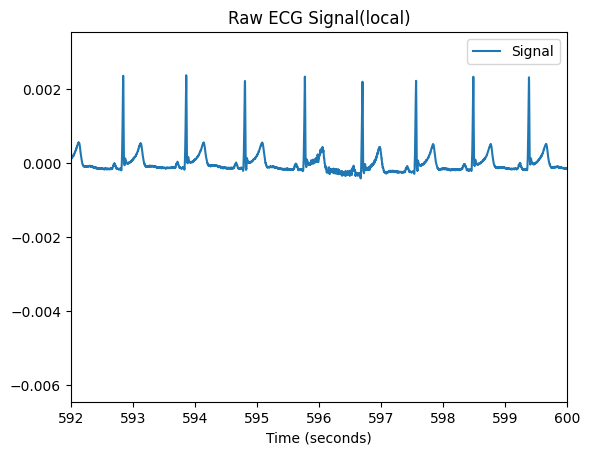

In [7]:
#raw signal
nk.signal_plot(ecg_signal, sampling_rate=sr)
plt.title("Raw ECG Signal(local)")
plt.xlim(592, 600)

In [8]:
# processing data
# Define a new function for processing pipline
def my_processing(ecg_signal):
    """
    Method used in Pan & Tompkins (1985): band-pass filter between 5 and 15 Hz using a Butterworth filter 
    (with zi provided - initial zero-input response provided to avoid transient artifact at beginning). -- copied from neurokit2 manual
    I use this method since it procudes clearest R peak and reasonable HR without artifacts
    
    this function clean the raw signal with method I choose, then calculate the heart rate and check the quality
    after processing, wrap all the data into dataframe with an information dictionary and plot the result
    """
    #process
    ecg_cleaned = nk.ecg_clean(ecg_signal, sampling_rate = sr, method="pantompkins1985")
    (
        instant_peaks,
        rpeaks,
    ) = nk.ecg_peaks(ecg_cleaned, sampling_rate=sr)
    rate = nk.ecg_rate(rpeaks, sampling_rate=sr, desired_length=len(ecg_cleaned))
    quality = nk.ecg_quality(ecg_cleaned, sampling_rate=sr, method="ho2025")

    #dataframe
    signals = pd.DataFrame({"ECG_Raw": ecg_signal, "ECG_Clean": ecg_cleaned, "ECG_Rate": rate, "ECG_Quality": quality})
    signals = pd.concat([signals, instant_peaks], axis=1)

    # info dict
    info = rpeaks
    info["sampling_rate"] = sr
    
    plt.rcParams['figure.figsize'] = [15, 8]
    nk.ecg_plot(signals,info)
    plt.tight_layout()
    plt.show()

    return signals, info

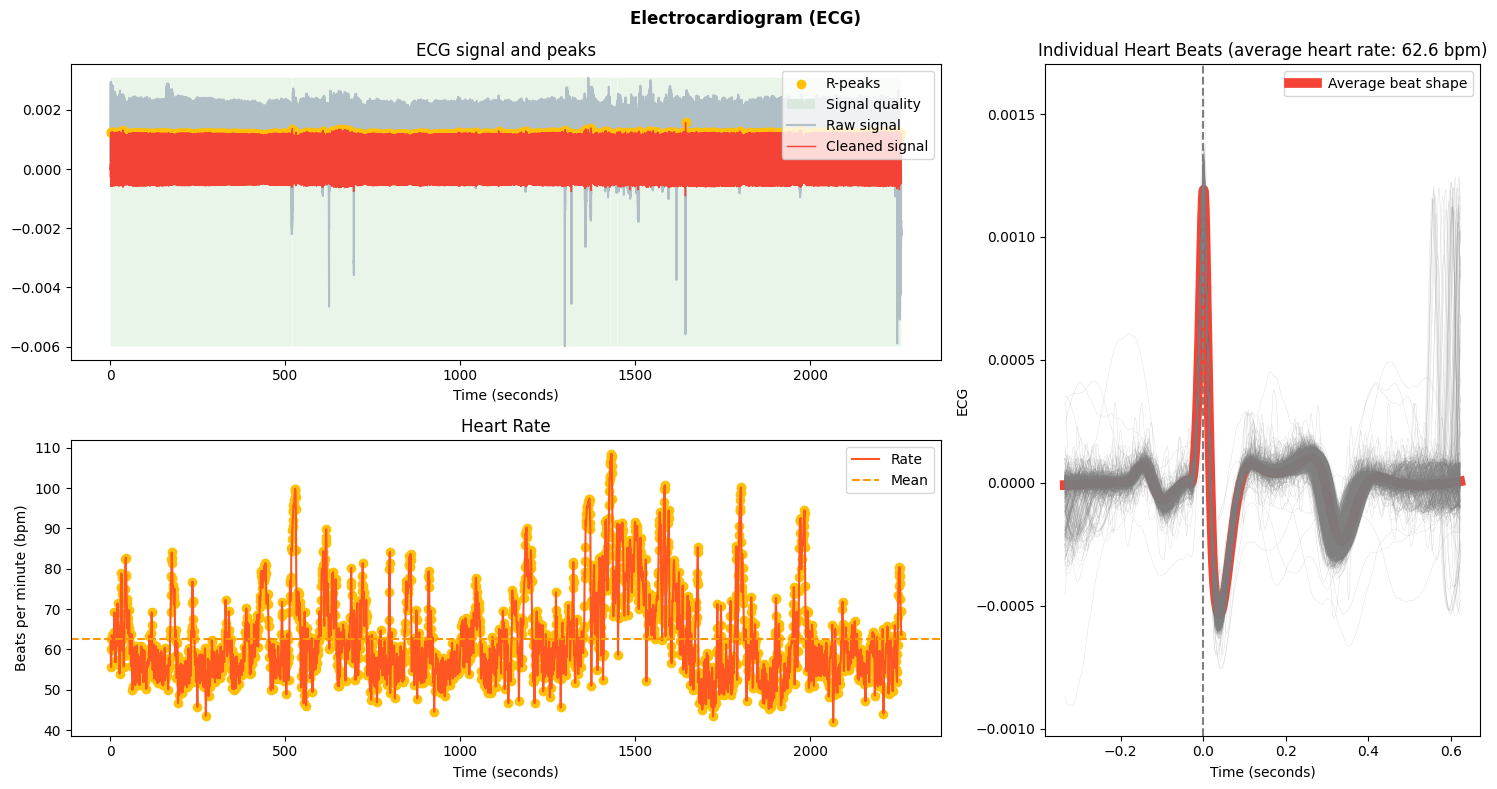

In [9]:

ecg_signals,info = my_processing(ecg_signal)


In [ ]:
#check R peaks accuracy
#plot clean ecg with R peaks  
plt.figure(figsize=(15, 5))


plt.plot(ecg_signals["ECG_Clean"], color="red", label="Cleaned ECG", linewidth=1.5)

r_peaks_indices = info["ECG_R_Peaks"]
plt.scatter(r_peaks_indices, ecg_signals["ECG_Clean"].iloc[r_peaks_indices], 
            color="orange", marker="x", s=50, zorder=5, label="R-peaks")

plt.title("Cleaned ECG Signal with Detected R-Peaks", fontsize=16)
plt.xlabel("Time (Samples)", fontsize=12)
plt.ylabel("Amplitude", fontsize=12)
plt.legend(loc="upper right")

#select the the zone
#need to check 323314-623314 / 997322-1297322 / 1947315-2247315
#check 100000 samples each time
plt.xlim(2147315, 2247315) 

plt.show()

In [10]:
#find markers
markers = nk.events_find(marker_signal)

#marker I want to use
marker = {
    "onset": np.array([623314, 1297322, 2247315]),
    "duration": np.array([1379, 1380, 1380]),
    "label": np.array(['Baseline', 'Stress + Silence', 'Stress + Audio Frequency'])
}

In [11]:
# use marker(event) creat epoch, each epoch start from -300s to 0s
epochs = nk.epochs_create(ecg_signals, marker, sampling_rate=sr, epochs_start=-300, epochs_end=0)
epochs

{np.str_('Baseline'):            ECG_Raw  ECG_Clean   ECG_Rate  ECG_Quality  ECG_R_Peaks   Index  \
 -300.000 -0.000069  -0.000122  57.803770            1            0  323314   
 -299.999 -0.000054  -0.000179  57.803804            1            0  323315   
 -299.998 -0.000035  -0.000231  57.803840            1            0  323316   
 -299.997  0.000008  -0.000278  57.803878            1            0  323317   
 -299.996  0.000049  -0.000319  57.803917            1            0  323318   
 ...            ...        ...        ...          ...          ...     ...   
 -0.004    0.000056   0.000062  64.276018            1            0  623309   
 -0.003    0.000049   0.000061  64.274131            1            0  623310   
 -0.002    0.000048   0.000060  64.272247            1            0  623311   
 -0.001    0.000050   0.000059  64.270368            1            0  623312   
  0.000    0.000055   0.000057  64.268491            1            0  623313   
 
              Label  
 -300.0

/Users/ashafe/Library/Python/3.12/lib/python/site-packages/neurokit2/ecg/ecg_plot.py:68: NeuroKitWarning: 'info' dict not provided. Some information might be missing. Sampling rate will be set to 1000 Hz.
  warn(
/Users/ashafe/Library/Python/3.12/lib/python/site-packages/neurokit2/ecg/ecg_plot.py:68: NeuroKitWarning: 'info' dict not provided. Some information might be missing. Sampling rate will be set to 1000 Hz.
  warn(
/Users/ashafe/Library/Python/3.12/lib/python/site-packages/neurokit2/stats/rescale.py:67: RuntimeWarning: divide by zero encountered in scalar divide
  return (to[1] - to[0]) / (scale[1] - scale[0]) * (data - scale[0]) + to[0]
/Users/ashafe/Library/Python/3.12/lib/python/site-packages/neurokit2/stats/rescale.py:67: RuntimeWarning: invalid value encountered in multiply
  return (to[1] - to[0]) / (scale[1] - scale[0]) * (data - scale[0]) + to[0]
/Users/ashafe/Library/Python/3.12/lib/python/site-packages/neurokit2/ecg/ecg_plot.py:68: NeuroKitWarning: 'info' dict not prov

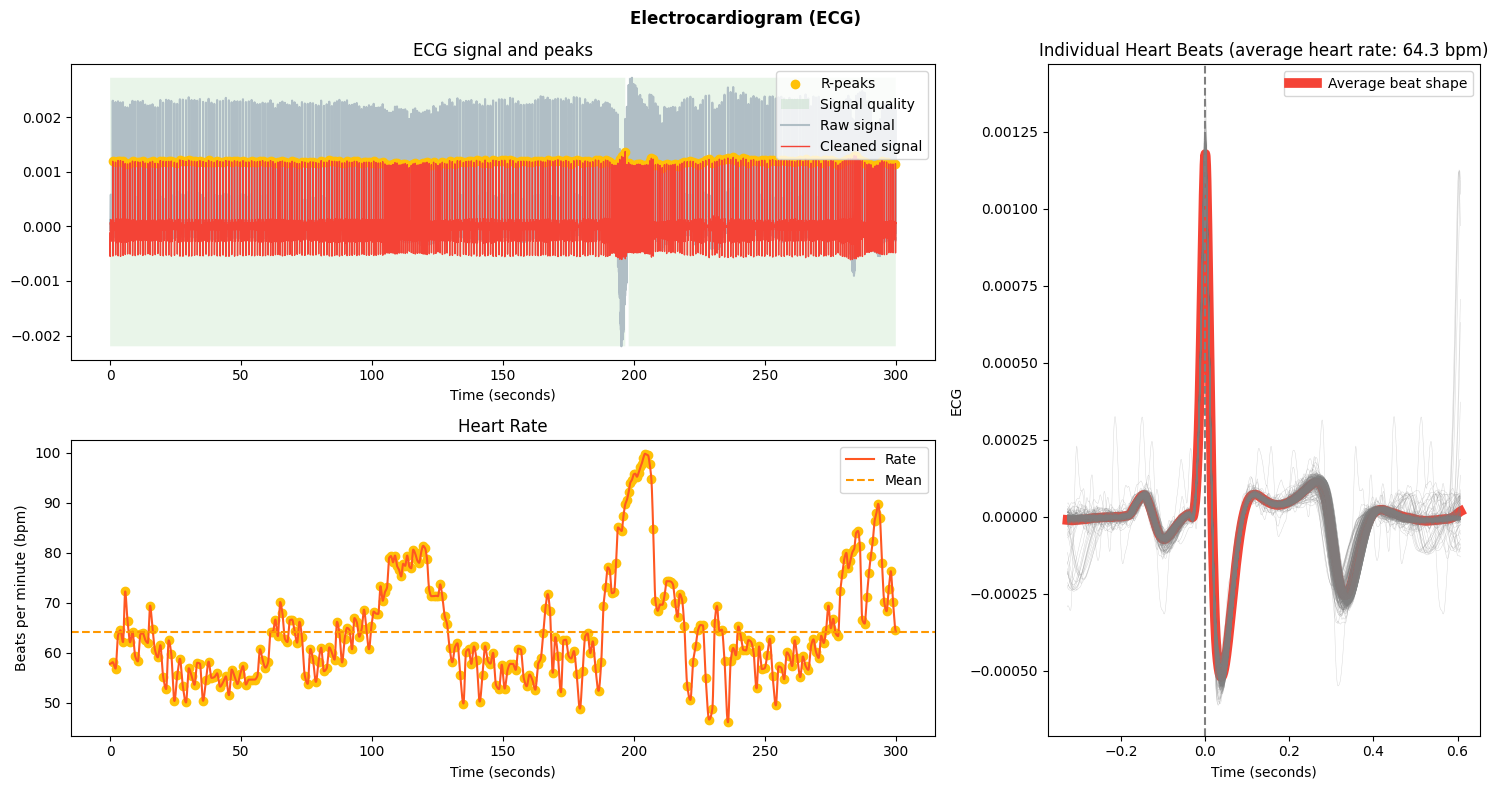

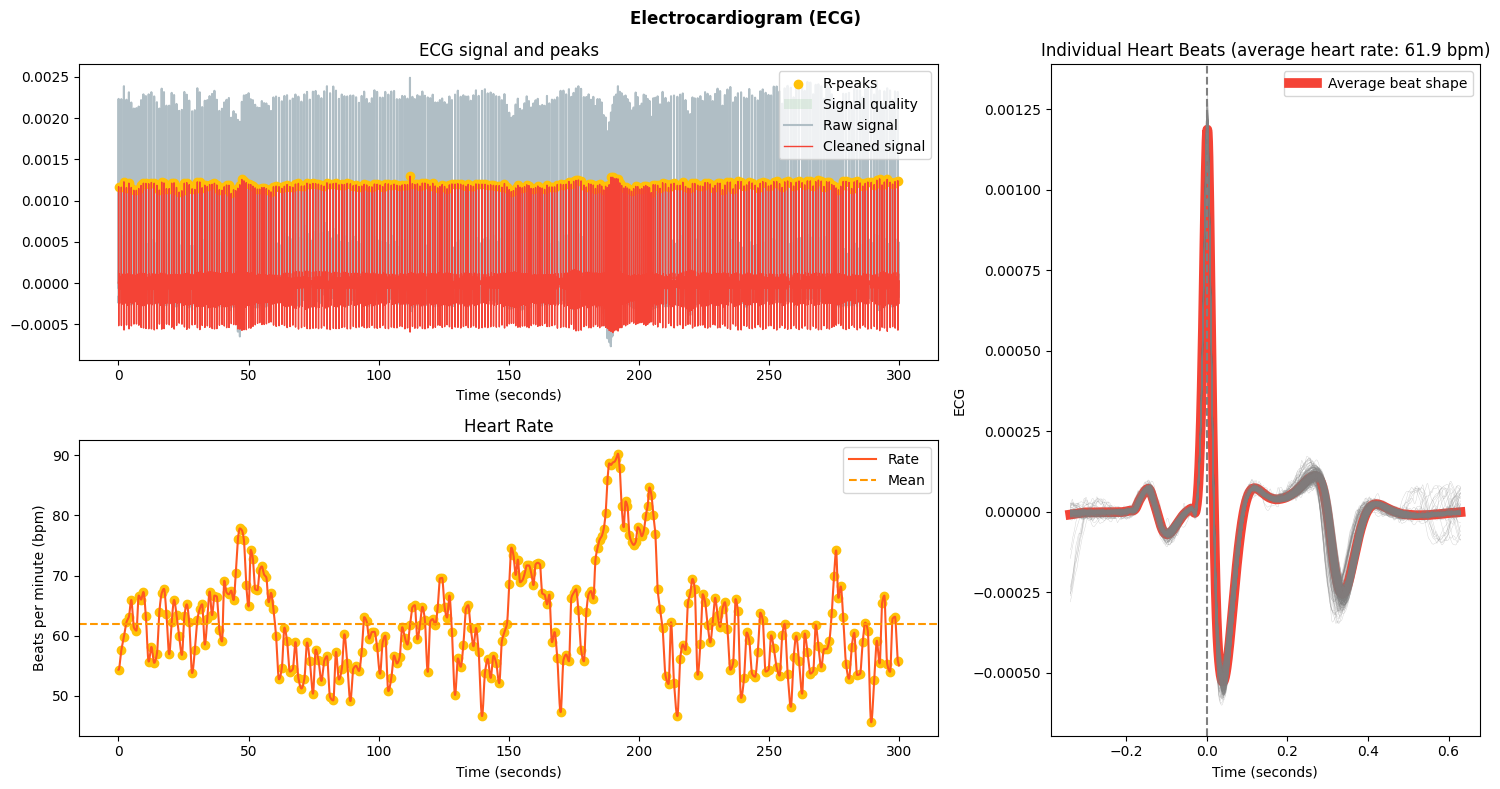

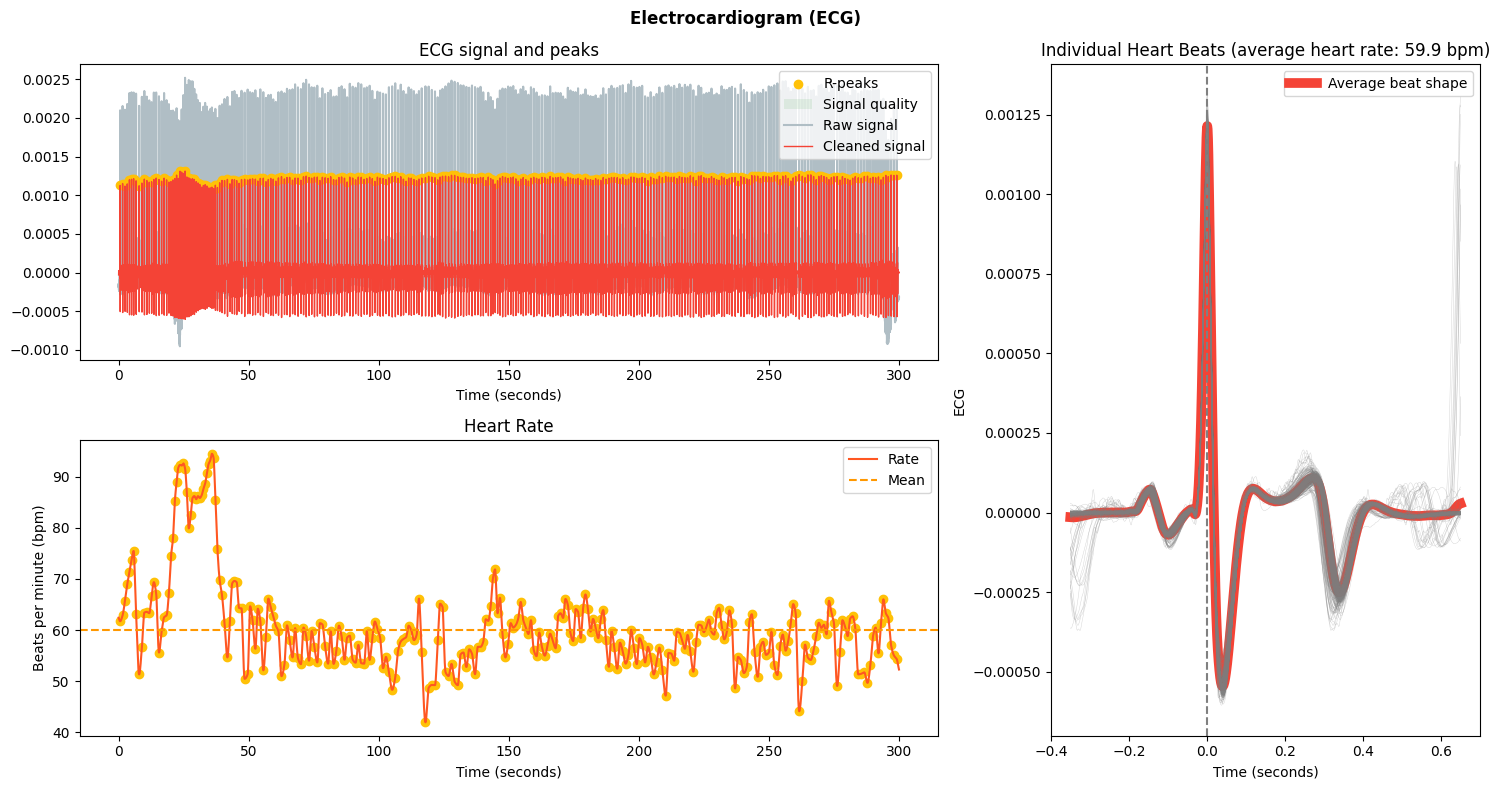

In [12]:
# plot ECG profile for each plot
for epoch in epochs.values():
    nk.ecg_plot(epoch)
    plt.tight_layout()

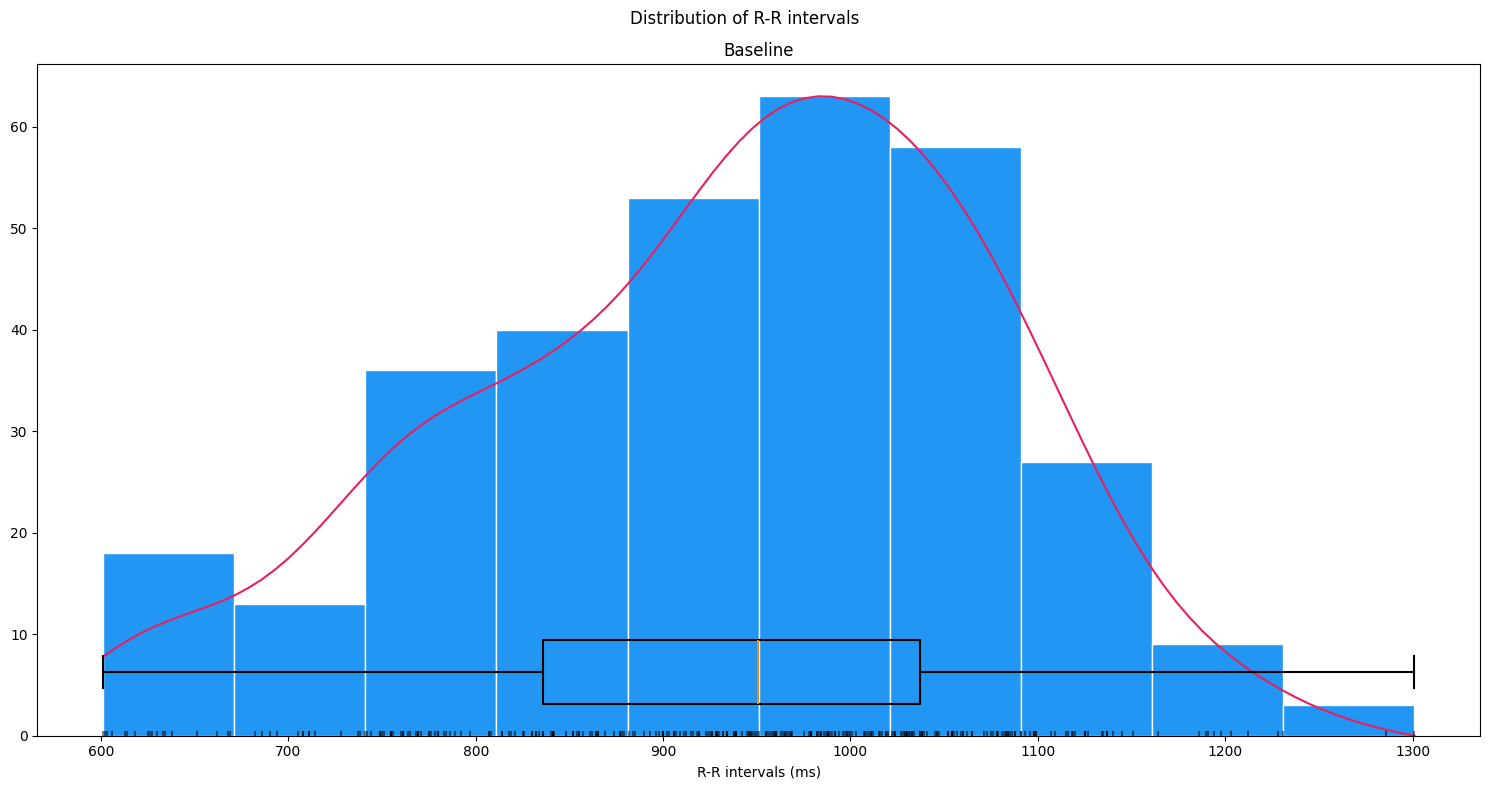

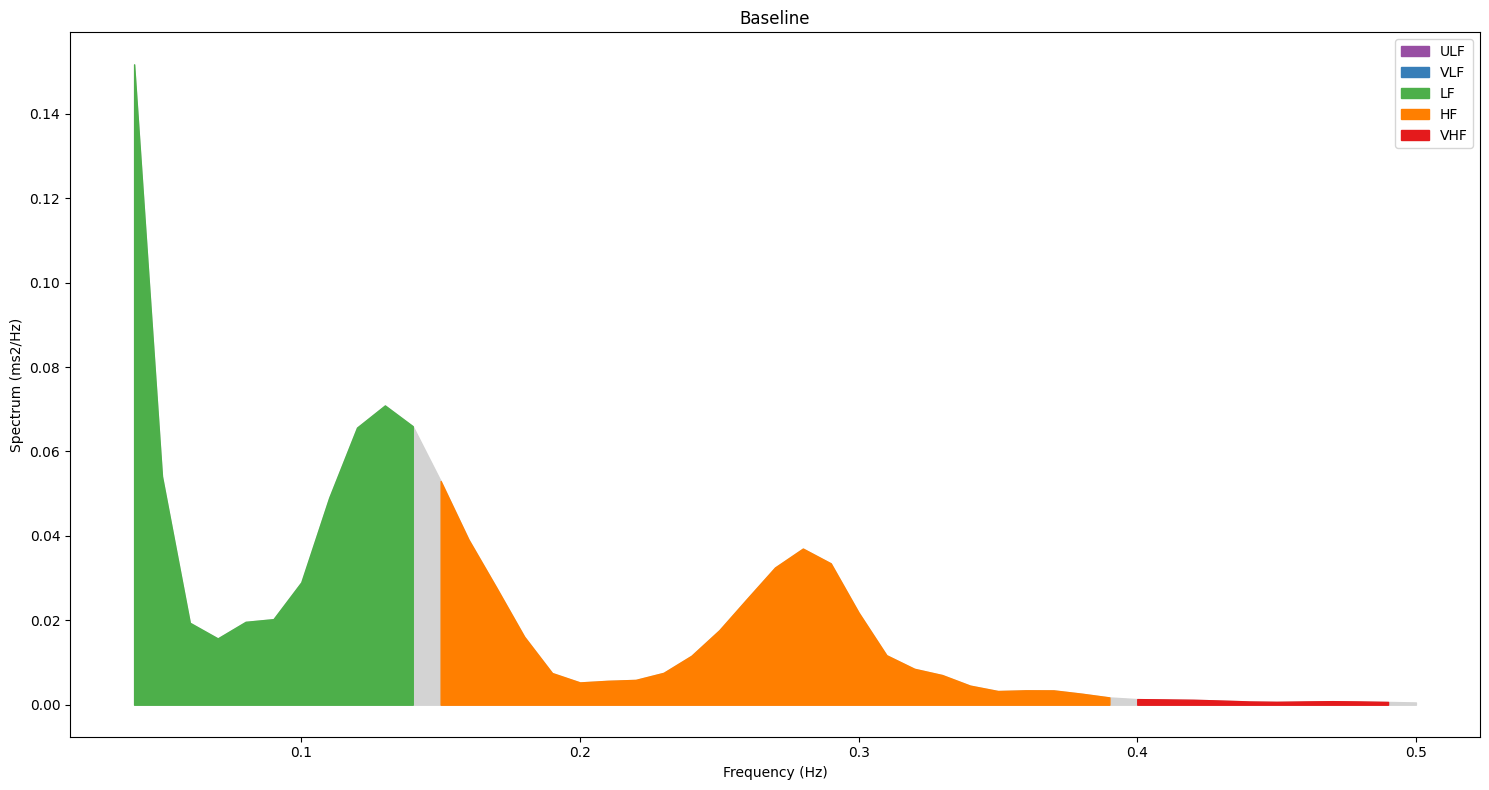

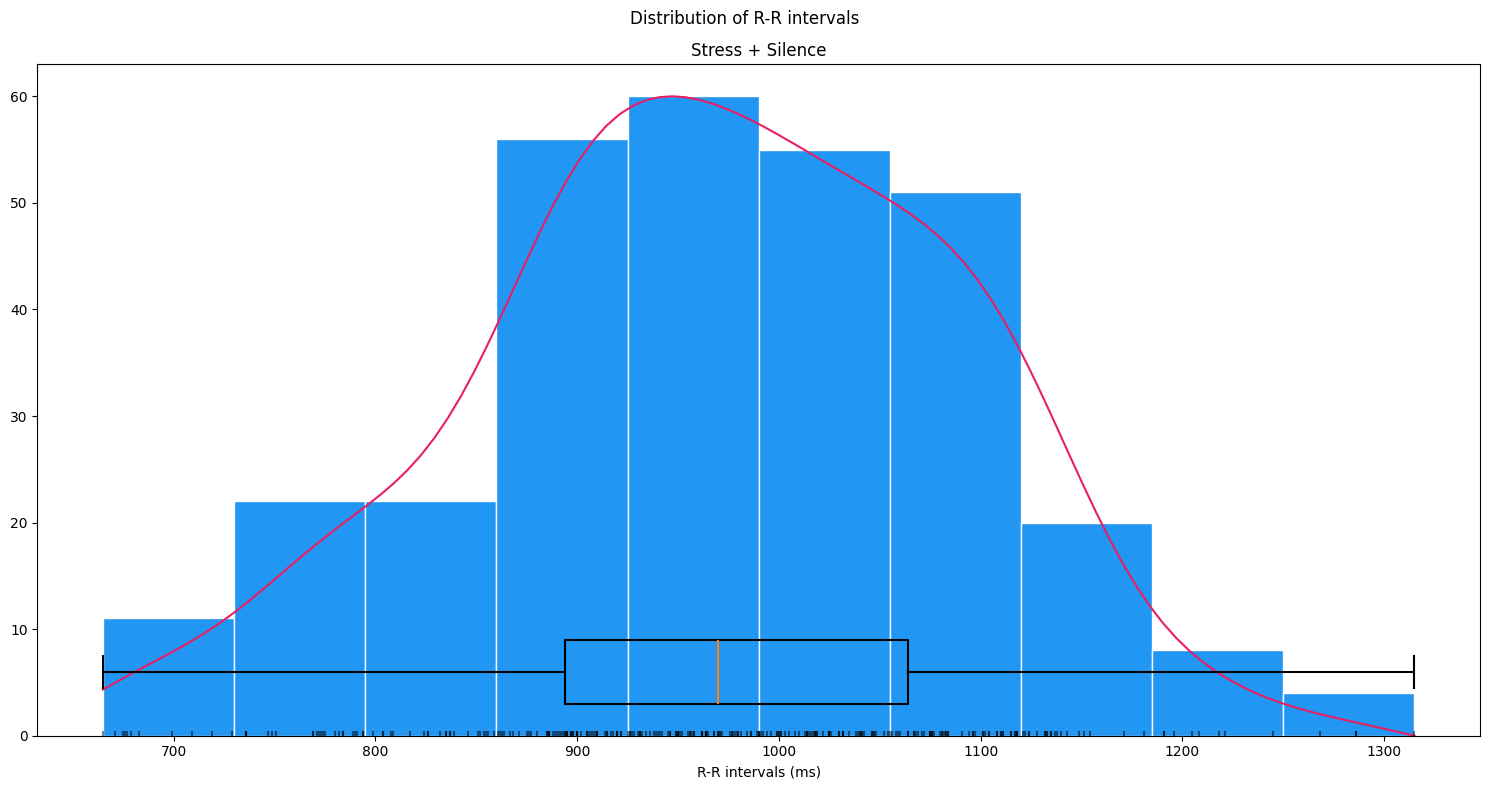

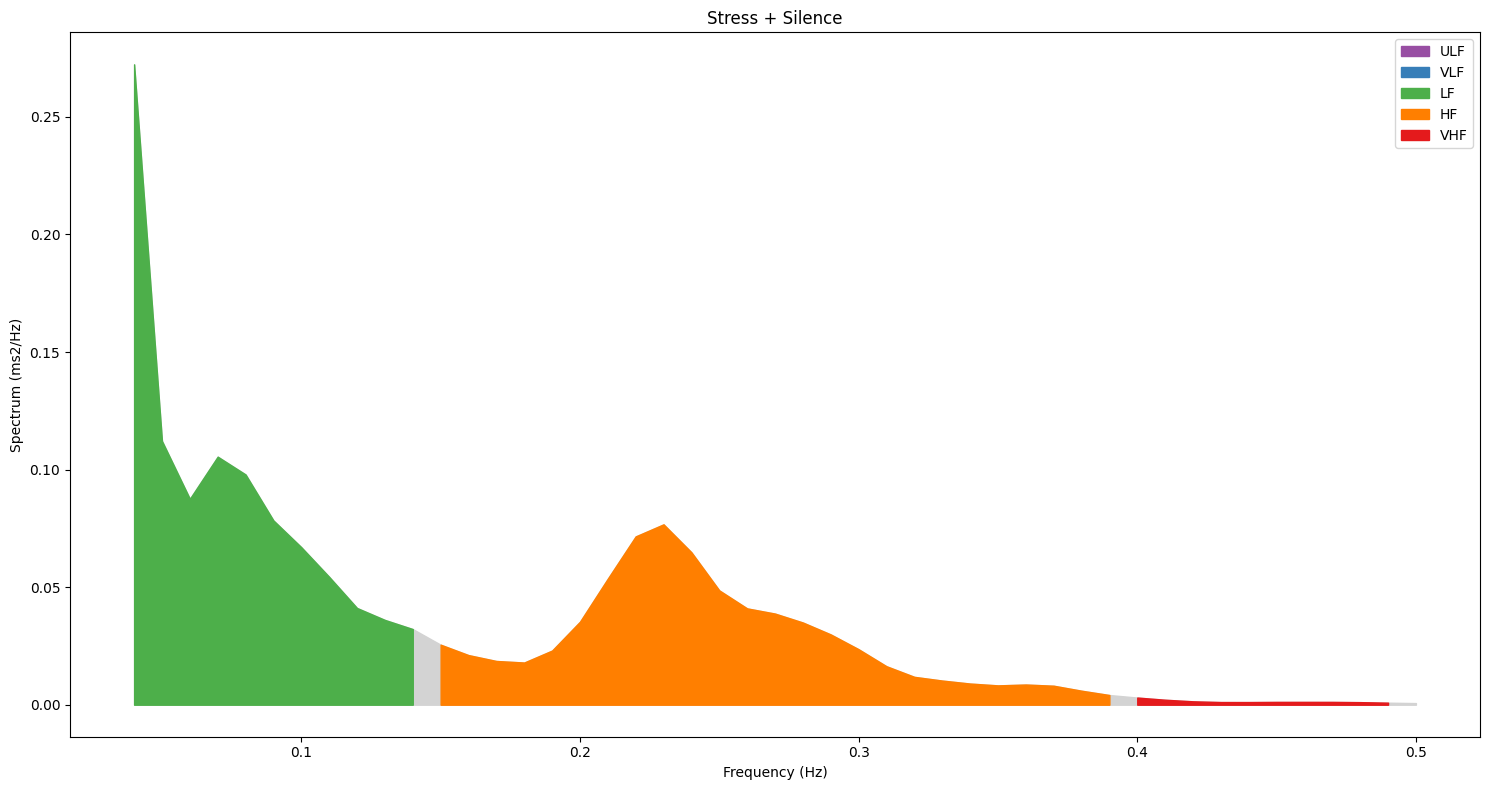

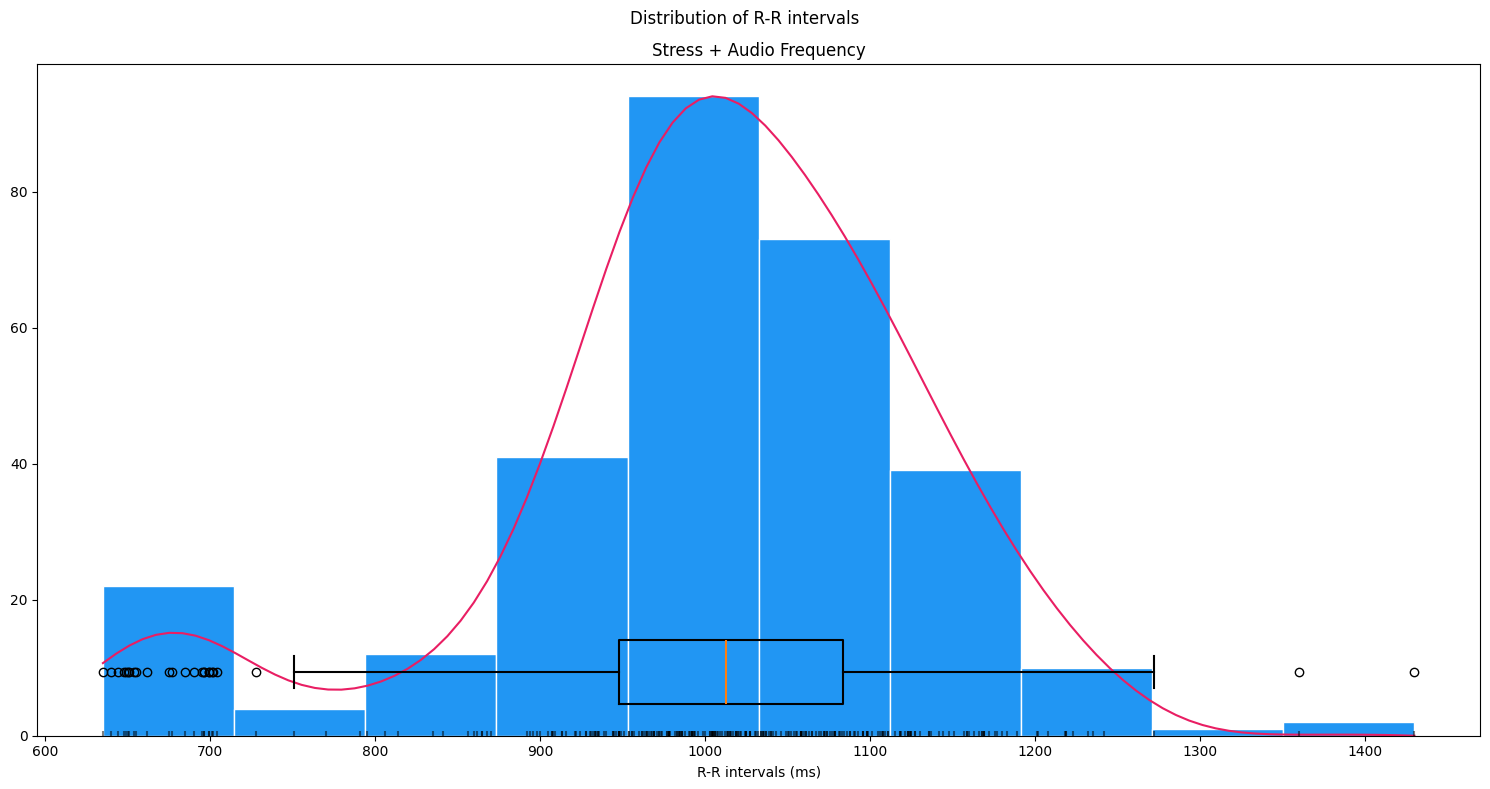

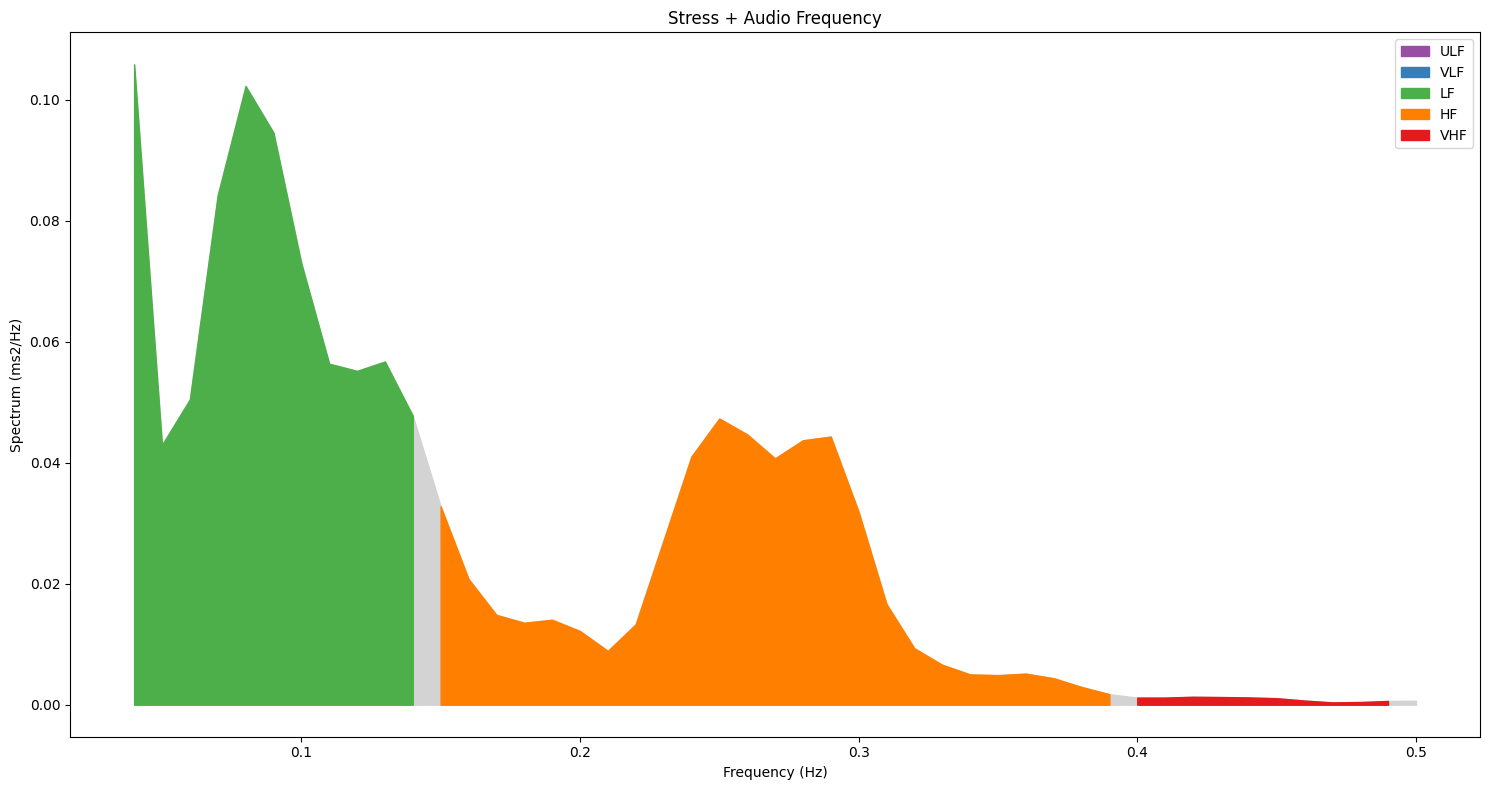

In [13]:
hrv_results_time = []
hrv_results_freq = []
for label_name, epoch_df in epochs.items():
    peaks_loc = epoch_df[epoch_df["ECG_R_Peaks"] == 1]["Index"].values
    
    #time domain
    hrv_t = nk.hrv_time(peaks_loc, sampling_rate = sr, show=True)
    plt.title(label_name)
    plt.tight_layout()
    hrv_t.insert(0, "Session", label_name)
    hrv_results_time.append(hrv_t)
    

    #frequency domain
    #plt.rcParams["figure.figsize"] = [12,8]   
    hrv_f = nk.hrv_frequency(peaks_loc, sampling_rate = sr, show=True)
    plt.title(label_name)
    plt.tight_layout()
    hrv_f.insert(0, "Session", label_name)
    hrv_results_freq.append(hrv_f)

hrvtab_time = pd.concat(hrv_results_time, ignore_index=True)
hrvtab_freq = pd.concat(hrv_results_freq, ignore_index=True)


In [ ]:
hrvtab_time
#hrvtab_time.to_csv("[filename].csv")

In [ ]:
hrvtab_freq
#hrvtab_freq.to_csv("[filename].csv")

{'Mean_HR': np.float64(64.25478080660041),
 'Mean_NN': np.float64(933.871875),
 'SDNN': np.float64(143.73545173076698),
 'pNN50': np.float64(39.6875),
 'RMSSD': np.float64(73.50051713293436),
 'LF': np.float64(0.0031627872181707326),
 'HF': np.float64(0.002263904927612249),
 'LF_HF_Ratio': np.float64(1.3970494871913808)}

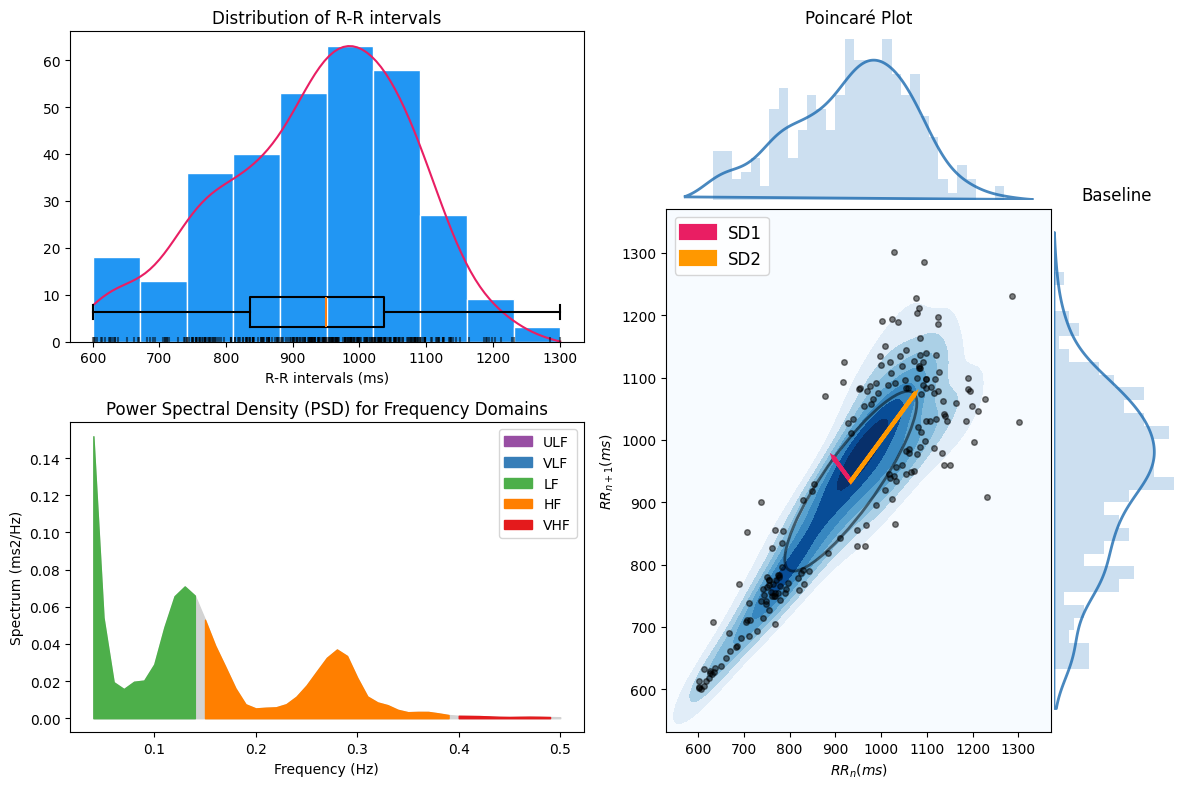

In [14]:
#baseline -- double check + extract metrics
df_seg1 = epochs["Baseline"]
peaks_seg1 = df_seg1[df_seg1["ECG_R_Peaks"] == 1]["Index"].values
plt.rcParams["figure.figsize"] = [12,8]
hrv_seg1 = nk.hrv(peaks_seg1, sampling_rate=sr, show=True)
plt.title("Baseline")
plt.tight_layout()
baseline = {
    "Mean_HR": df_seg1["ECG_Rate"].mean(),
    "Mean_NN": hrv_seg1["HRV_MeanNN"].values[0],
    "SDNN": hrv_seg1["HRV_SDNN"].values[0],
    "pNN50": hrv_seg1["HRV_pNN50"].values[0],
    "RMSSD": hrv_seg1["HRV_RMSSD"].values[0],
    "LF": hrv_seg1["HRV_LF"].values[0],
    "HF": hrv_seg1["HRV_HF"].values[0],
    "LF_HF_Ratio": hrv_seg1["HRV_LFHF"].values[0]
}

baseline


{'Mean_HR': np.float64(61.93042903436912),
 'Mean_NN': np.float64(969.3203883495146),
 'SDNN': np.float64(125.73368167019609),
 'pNN50': np.float64(46.27831715210356),
 'RMSSD': np.float64(83.29179267654604),
 'LF': np.float64(0.005754069240365426),
 'HF': np.float64(0.004915199984623501),
 'LF_HF_Ratio': np.float64(1.170668387525677)}

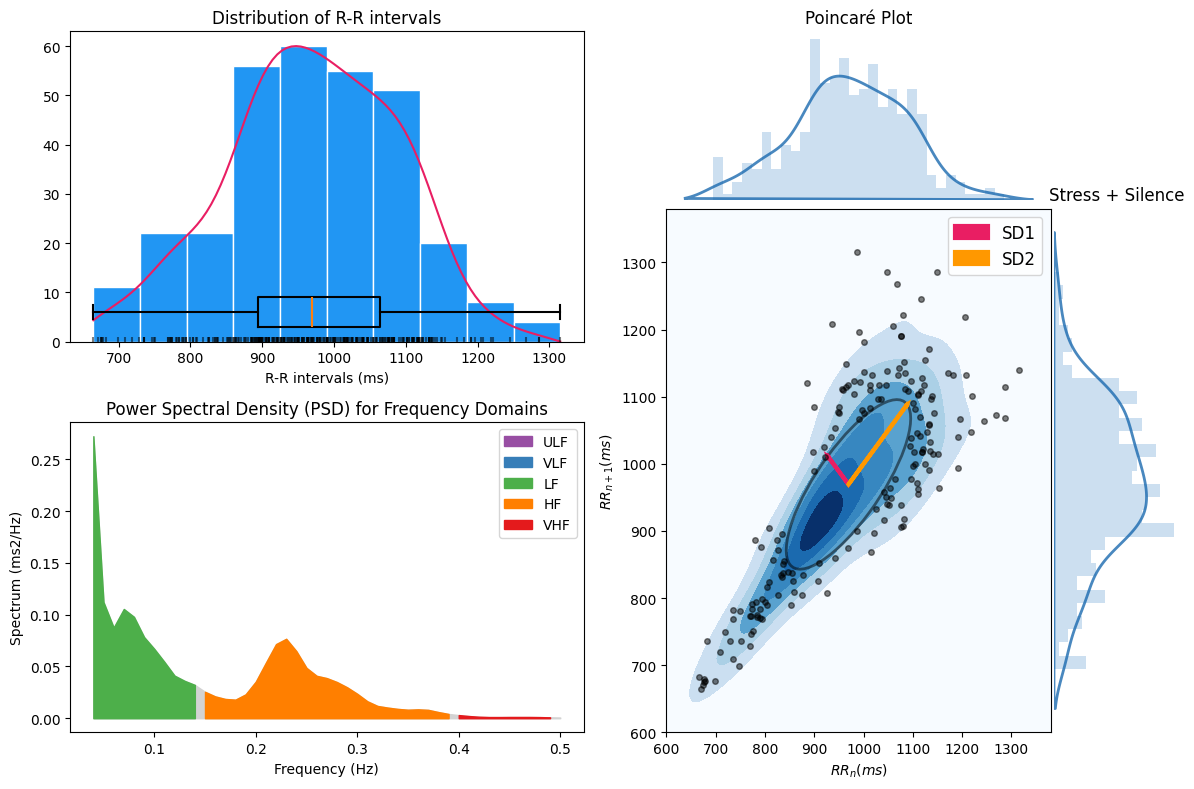

In [15]:
#without frequency -- double check + extract metrics
df_seg2 = epochs["Stress + Silence"]
peaks_seg2 = df_seg2[df_seg2["ECG_R_Peaks"] == 1]["Index"].values
plt.rcParams["figure.figsize"] = [12,8]
hrv_seg2 = nk.hrv(peaks_seg2, sampling_rate=sr, show=True)
plt.title("Stress + Silence")
plt.tight_layout()
no_freq = {
    "Mean_HR": df_seg2["ECG_Rate"].mean(),
    "Mean_NN": hrv_seg2["HRV_MeanNN"].values[0],
    "SDNN": hrv_seg2["HRV_SDNN"].values[0],
    "pNN50": hrv_seg2["HRV_pNN50"].values[0],
    "RMSSD": hrv_seg2["HRV_RMSSD"].values[0],
    "LF": hrv_seg2["HRV_LF"].values[0],
    "HF": hrv_seg2["HRV_HF"].values[0],
    "LF_HF_Ratio": hrv_seg2["HRV_LFHF"].values[0]
}

no_freq


{'Mean_HR': np.float64(59.92610174704596),
 'Mean_NN': np.float64(1001.9127516778524),
 'SDNN': np.float64(133.719437573583),
 'pNN50': np.float64(47.98657718120805),
 'RMSSD': np.float64(85.0817986288046),
 'LF': np.float64(0.009947765219500408),
 'HF': np.float64(0.00806322365835249),
 'LF_HF_Ratio': np.float64(1.2337206111349484)}

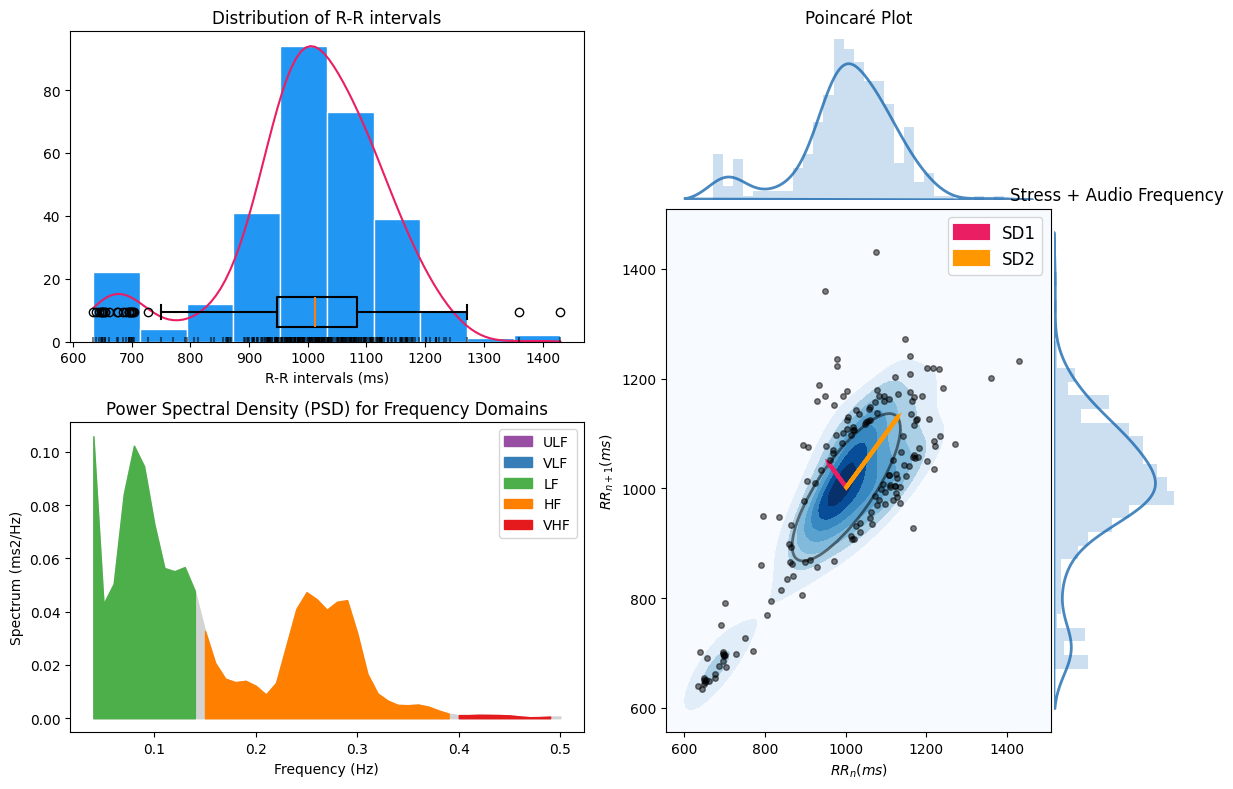

In [16]:
#with frequency -- double check + extract metrics
df_seg3 = epochs["Stress + Audio Frequency"]
peaks_seg3 = df_seg3[df_seg3["ECG_R_Peaks"] == 1]["Index"].values
plt.rcParams["figure.figsize"] = [12,8]
hrv_seg3 = nk.hrv(peaks_seg3, sampling_rate=sr, show=True)
plt.title("Stress + Audio Frequency")
plt.tight_layout()
w_freq = {
    "Mean_HR": df_seg3["ECG_Rate"].mean(),
    "Mean_NN": hrv_seg3["HRV_MeanNN"].values[0],
    "SDNN": hrv_seg3["HRV_SDNN"].values[0],
    "pNN50": hrv_seg3["HRV_pNN50"].values[0],
    "RMSSD": hrv_seg3["HRV_RMSSD"].values[0],
    "LF": hrv_seg3["HRV_LF"].values[0],
    "HF": hrv_seg3["HRV_HF"].values[0],
    "LF_HF_Ratio": hrv_seg3["HRV_LFHF"].values[0]
}

w_freq


In [18]:
#make a table
results = pd.DataFrame([baseline,no_freq,w_freq], index=["Baseline", "Stress + Silence", "Stress + Audio Frequency"])
results

,Mean_HR,Mean_NN,SDNN,pNN50,RMSSD,LF,HF,LF_HF_Ratio
Baseline,64.254781,933.871875,143.735452,39.687500,73.500517,0.003163,0.002264,1.397049
Stress + Silence,61.930429,969.320388,125.733682,46.278317,83.291793,0.005754,0.004915,1.170668
Stress + Audio Frequency,59.926102,1001.912752,133.719438,47.986577,85.081799,0.009948,0.008063,1.233721


In [19]:
results['LF'] = results['LF'] * 1000000
results['HF'] = results['HF'] * 1000000

results

,Mean_HR,Mean_NN,SDNN,pNN50,RMSSD,LF,HF,LF_HF_Ratio
Baseline,64.254781,933.871875,143.735452,39.687500,73.500517,3162.787218,2263.904928,1.397049
Stress + Silence,61.930429,969.320388,125.733682,46.278317,83.291793,5754.069240,4915.199985,1.170668
Stress + Audio Frequency,59.926102,1001.912752,133.719438,47.986577,85.081799,9947.765220,8063.223658,1.233721


In [ ]:
results.to_csv("ecg results for three 5-min windows.csv")

In [ ]:
# reset the index since result use string as index
plot_df = results.reset_index() 

#Mean HR
plt.figure(figsize=(8, 6))
sns.barplot(data=plot_df, x='index', y='Mean_HR', palette='Set2')

plt.title('Average HR by Condition')
plt.ylabel('Heart Beat (bpm)')
plt.xlabel('Condition')
plt.ylim(0,80)
plt.show()

In [ ]:
# reset the index since result use string as index
plot_df = results.reset_index() 

#RMSSD
plt.figure(figsize=(8, 6))
sns.barplot(data=plot_df, x='index', y='RMSSD', palette='Set2')

plt.title('Average RMSSD by Condition')
plt.ylabel('RMSSD (ms)')
plt.xlabel('Condition')
plt.ylim(0,110)
plt.show()

In [ ]:
# reset the index since result use string as index
plot_df = results.reset_index() 

#Mean NN
plt.figure(figsize=(8, 6))
sns.barplot(data=plot_df, x='index', y='Mean_NN', palette='Set2')

plt.title('Average NN interval by Condition')
plt.ylabel('NN (ms)')
plt.xlabel('Condition')
plt.ylim(0,1200)
plt.show()

In [ ]:
# reset the index since result use string as index
plot_df = results.reset_index() 

#Mean HR
plt.figure(figsize=(8, 6))
sns.barplot(data=plot_df, x='index', y='SDNN', palette='Set2')

plt.title('SDNN by Condition')
plt.ylabel('SDNN (ms)')
plt.xlabel('Condition')
plt.ylim(0,180)
plt.show()

In [ ]:
# reset the index since result use string as index
plot_df = results.reset_index() 

#Mean HR
plt.figure(figsize=(8, 6))
sns.barplot(data=plot_df, x='index', y='pNN50', palette='Set2')

plt.title('pNN50 by Condition')
plt.ylabel('pNN50 (%)')
plt.xlabel('Condition')
plt.ylim(0,100)
plt.show()

In [ ]:
# reset the index since result use string as index
plot_df = results.reset_index() 

#Mean HR
plt.figure(figsize=(8, 6))
sns.barplot(data=plot_df, x='index', y='LF', palette='Set2')

plt.title('LF by Condition')
plt.ylabel('Low frequency (ms²)')
plt.xlabel('Condition')
plt.ylim(0,12000)
plt.show()

In [ ]:

plt.figure(figsize=(9, 6))


ax = sns.barplot(data=plot_df, x='index', y='LF', hue='index', palette='Set2', legend=False)

for p in ax.patches:
    height = p.get_height()
    height_t = 500

    ax.text(p.get_x() + p.get_width() / 2., height_t , 
            f'{height:.2f}',
            ha='center', va='top', color='black', fontsize=12)

def annotate_bars(ax, x1, x2, base_height, text):
    """Draws a bracket and percentage text between two bars."""
    prong_height = 0.0005 
    y_flat = base_height + prong_height

    ax.plot([x1, x1, x2, x2], [base_height, y_flat, y_flat, base_height], lw=1.5, color='black')

    ax.text((x1+x2)*0.5, y_flat + 0.0002, text, 
            ha='center', va='bottom', color='black', fontweight='bold', fontsize=11)


y_bar1 = plot_df['LF'].iloc[0] # Baseline
y_bar2 = plot_df['LF'].iloc[1] # Stress + Silence
y_bar3 = plot_df['LF'].iloc[2] # Stress + Audio Frequency


annotate_bars(ax, x1=0, x2=1, base_height=y_bar2 + 500, text="+81.9%")

annotate_bars(ax, x1=1, x2=2, base_height=y_bar3 + 500, text="+72.9%")

annotate_bars(ax, x1=0, x2=2, base_height=max(y_bar1, y_bar3) + 1300, text="+214.5%")

plt.title('Effect of Condition on Low Frequency (LF) Power', pad=15)
plt.ylabel('Low Frequency (ms²)')
plt.xlabel('Condition')

plt.ylim(0, 12000) 

plt.tight_layout()
plt.show()

In [ ]:

plt.figure(figsize=(9, 6))


ax = sns.barplot(data=plot_df, x='index', y='HF', hue='index', palette='Set2', legend=False)

for p in ax.patches:
    height = p.get_height()
    height_t = 500

    ax.text(p.get_x() + p.get_width() / 2., height_t , 
            f'{height:.2f}',
            ha='center', va='top', color='black', fontsize=12)

def annotate_bars(ax, x1, x2, base_height, text):
    """Draws a bracket and percentage text between two bars."""
    prong_height = 0.0005 
    y_flat = base_height + prong_height

    ax.plot([x1, x1, x2, x2], [base_height, y_flat, y_flat, base_height], lw=1.5, color='black')

    ax.text((x1+x2)*0.5, y_flat + 0.0002, text, 
            ha='center', va='bottom', color='black', fontweight='bold', fontsize=11)


y_bar1 = plot_df['HF'].iloc[0] # Baseline
y_bar2 = plot_df['HF'].iloc[1] # Stress + Silence
y_bar3 = plot_df['HF'].iloc[2] # Stress + Audio Frequency


annotate_bars(ax, x1=0, x2=1, base_height=y_bar2 + 500, text="+117.1%")

annotate_bars(ax, x1=1, x2=2, base_height=y_bar3 + 500, text="+64.0%")

annotate_bars(ax, x1=0, x2=2, base_height=max(y_bar1, y_bar3) + 1300, text="+256.2%")

plt.title('Effect of Condition on High Frequency (HF) Power', pad=15)
plt.ylabel('High Frequency (ms²)')
plt.xlabel('Condition')

plt.ylim(0, 10000) 

plt.tight_layout()
plt.show()

In [ ]:
# reset the index since result use string as index
plot_df = results.reset_index() 

#Mean HR
plt.figure(figsize=(8, 6))
sns.barplot(data=plot_df, x='index', y='HF', palette='Set2')

plt.title('HF by Condition')
plt.ylabel('High Frequency (ms²)')
plt.xlabel('Condition')
plt.ylim(0,10000)
plt.show()

In [ ]:
# 1. Draw the basic bar plot 
# (Adding hue='index' and legend=False fixes your Future Warning!)
ax = sns.barplot(data=plot_df, x='index', y='HF', hue='index', palette='Set2', legend=False)

# 2. Define a helper function to draw the brackets
def annotate_bars(ax, x1, x2, base_height, text):
    """Draws a bracket and percentage text between two bars."""
    # The height of the little downward prongs on the bracket
    prong_height = 0.0005 
    # The vertical position of the flat horizontal line
    y_flat = base_height + prong_height
    
    # Draw the bracket lines: [left prong, flat top, right prong]
    ax.plot([x1, x1, x2, x2], [base_height, y_flat, y_flat, base_height], lw=1.5, color='black')
    
    # Add the text in the middle, slightly above the flat line
    ax.text((x1+x2)*0.5, y_flat + 0.0002, text, 
            ha='center', va='bottom', color='black', fontweight='bold', fontsize=11)

# 3. Get the heights of your bars so the brackets don't crash into them
y_bar1 = plot_df['HF'].iloc[0] # Baseline
y_bar2 = plot_df['HF'].iloc[1] # Stress + Silence
y_bar3 = plot_df['HF'].iloc[2] # Stress + Audio Frequency

# 4. Draw the brackets using the data from your final_table

# Bracket 1: Baseline vs Stress + Silence 
# We put this slightly above Bar 2
annotate_bars(ax, x1=0, x2=1, base_height=y_bar2 + 500, text="+117.1%")

# Bracket 2: Stress + Silence vs Stress + Audio
# We put this slightly above Bar 3
annotate_bars(ax, x1=1, x2=2, base_height=y_bar3 + 500, text="+64.0%")

# Bracket 3: The massive overarching bracket (Baseline vs Audio)
# We put this one highest so it arches over the others
annotate_bars(ax, x1=0, x2=2, base_height=max(y_bar1, y_bar3) + 1300, text="+256.2%")


# 5. Clean up labels
plt.title('Effect of Condition on High Frequency (HF) Power', pad=15)
plt.ylabel('Low Frequency (ms²)')
plt.xlabel('Condition')

# IMPORTANT: Increase the y-limit to make room for the highest bracket!
# Since your top bracket sits around 0.013, we stretch the graph to 0.016
plt.ylim(0, 10000) 

plt.tight_layout()
plt.show()

In [ ]:
# reset the index since result use string as index
plot_df = results.reset_index() 

#Mean HR
plt.figure(figsize=(8, 6))
sns.barplot(data=plot_df, x='index', y='LF_HF_Ratio', palette='Set2')

plt.title('LF/HF by Condition')
plt.ylabel('LF/HF')
plt.xlabel('Condition')
plt.ylim(0,1.75)
plt.show()

In [26]:
sliding_results = []

for label_name, epoch_df in epochs.items():
    # slide a 60s window every 30s
    for start_time in range(0, 241, 30):
        start_idx = start_time * sr
        end_idx = (start_time + 60) * sr
        window_data = epoch_df.iloc[start_idx:end_idx]
        
        
        peaks = window_data[window_data["ECG_R_Peaks"] == 1]["Index"].values
        
        # calculate RMSSD only when there are at least 3 intervals
        if len(peaks) > 3:
            hrv_min = nk.hrv_time(peaks, sampling_rate=sr)
            
            # add condition label and select metrics I need
            hrv_min["Condition"] = label_name
            hrv_min["MeanHR"] = 60000 / hrv_min["HRV_MeanNN"]
            append_set = hrv_min[["Condition", "MeanHR", "HRV_MeanNN", "HRV_SDNN", "HRV_RMSSD"]]
            sliding_results.append(append_set)
            

# Create the master dataframe for your statistics
stats_df = pd.concat(sliding_results, ignore_index=True)

In [27]:
stats_df

,Condition,MeanHR,HRV_MeanNN,HRV_SDNN,HRV_RMSSD
0,Baseline,57.661616,1040.553571,81.734808,74.597465
1,Baseline,58.473636,1026.103448,78.761619,62.851119
2,Baseline,66.923545,896.545455,101.575464,51.049147
3,Baseline,67.037971,895.015152,121.520937,58.496811
4,Baseline,59.858976,1002.355932,105.627805,81.409459
5,Baseline,68.805019,872.029412,184.441470,71.146999
6,Baseline,70.699929,848.657143,178.050708,88.969707
7,Baseline,60.290211,995.186441,111.970820,101.940145
8,Baseline,66.027833,908.707692,130.983387,64.203655
9,Stress + Silence,64.522633,929.906250,77.189052,61.671814


In [ ]:
stats_df.to_csv("results for stats.csv")

In [20]:
# calculate delta and delta%
def get_delta(current, reference):
    return (current - reference)

def get_delta_pct(current, reference):
    return ((current - reference) / reference) * 100
    
# prepare final list for results (delta)
comparison_rows = []

In [21]:
# Row 1: Base -> No Freq
comparison_rows.append({
    "Comparison": "Base → No Freq",
    "Mean_HR (𝚫)": f"{get_delta(results.loc['Stress + Silence', 'Mean_HR'], results.loc['Baseline', 'Mean_HR']):.1f}",
    "Mean_NN (𝚫)": f"{get_delta(results.loc['Stress + Silence', 'Mean_NN'], results.loc['Baseline', 'Mean_NN']):.1f}",
    "SDNN (𝚫)": f"{get_delta(results.loc['Stress + Silence', 'SDNN'], results.loc['Baseline', 'SDNN']):.1f}",
    "pNN50 (𝚫)": f"{get_delta(results.loc['Stress + Silence', 'pNN50'], results.loc['Baseline', 'pNN50']):.1f}",
    "RMSSD (𝚫)": f"{get_delta(results.loc['Stress + Silence', 'RMSSD'], results.loc['Baseline', 'RMSSD']):.1f}",
    "LF (𝚫)": f"{get_delta(results.loc['Stress + Silence', 'LF'], results.loc['Baseline', 'LF']):.5f}",
    "HF (𝚫)": f"{get_delta(results.loc['Stress + Silence', 'HF'], results.loc['Baseline', 'HF']):.5f}",
    "LF/HF (𝚫)": f"{get_delta(results.loc['Stress + Silence', 'LF_HF_Ratio'], results.loc['Baseline', 'LF_HF_Ratio']):.1f}",
    "Mean_HR (𝚫%)": f"{get_delta_pct(results.loc['Stress + Silence', 'Mean_HR'], results.loc['Baseline', 'Mean_HR']):.1f}%",
    "Mean_NN (𝚫%)": f"{get_delta_pct(results.loc['Stress + Silence', 'Mean_NN'], results.loc['Baseline', 'Mean_NN']):.1f}%",
    "SDNN (𝚫%)": f"{get_delta_pct(results.loc['Stress + Silence', 'SDNN'], results.loc['Baseline', 'SDNN']):.1f}%",
    "RMSSD (𝚫%)": f"{get_delta_pct(results.loc['Stress + Silence', 'RMSSD'], results.loc['Baseline', 'RMSSD']):.1f}%",
    "LF (𝚫%)": f"{get_delta_pct(results.loc['Stress + Silence', 'LF'], results.loc['Baseline', 'LF']):.1f}%",
    "HF (𝚫%)": f"{get_delta_pct(results.loc['Stress + Silence', 'HF'], results.loc['Baseline', 'HF']):.1f}%",
    "LF/HF (𝚫%)": f"{get_delta_pct(results.loc['Stress + Silence', 'LF_HF_Ratio'], results.loc['Baseline', 'LF_HF_Ratio']):.1f}%",
    "What it Proves": "Horror images successfully induced response or not"
})


In [22]:
# Row 2: No Freq -> With Freq
comparison_rows.append({
    "Comparison": "Stress + Silence → Stress + Audio",
    "Mean_HR (𝚫)": f"{get_delta(results.loc['Stress + Audio Frequency', 'Mean_HR'], results.loc['Stress + Silence', 'Mean_HR']):.1f}",
    "Mean_NN (𝚫)": f"{get_delta(results.loc['Stress + Audio Frequency', 'Mean_NN'], results.loc['Stress + Silence', 'Mean_NN']):.1f}",
    "SDNN (𝚫)": f"{get_delta(results.loc['Stress + Audio Frequency', 'SDNN'], results.loc['Stress + Silence', 'SDNN']):.1f}",
    "pNN50 (𝚫)": f"{get_delta(results.loc['Stress + Audio Frequency', 'pNN50'], results.loc['Stress + Silence', 'pNN50']):.1f}",
    "RMSSD (𝚫)": f"{get_delta(results.loc['Stress + Audio Frequency', 'RMSSD'], results.loc['Stress + Silence', 'RMSSD']):.1f}",
    "LF (𝚫)": f"{get_delta(results.loc['Stress + Audio Frequency', 'LF'], results.loc['Stress + Silence', 'LF']):.5f}",
    "HF (𝚫)": f"{get_delta(results.loc['Stress + Audio Frequency', 'HF'], results.loc['Stress + Silence', 'HF']):.5f}",
    "LF/HF (𝚫)": f"{get_delta(results.loc['Stress + Audio Frequency', 'LF_HF_Ratio'], results.loc['Stress + Silence', 'LF_HF_Ratio']):.1f}",
    "Mean_HR (𝚫%)": f"{get_delta_pct(results.loc['Stress + Audio Frequency', 'Mean_HR'], results.loc['Stress + Silence', 'Mean_HR']):.1f}%",
    "Mean_NN (𝚫%)": f"{get_delta_pct(results.loc['Stress + Audio Frequency', 'Mean_NN'], results.loc['Stress + Silence', 'Mean_NN']):.1f}%",
    "SDNN (𝚫%)": f"{get_delta_pct(results.loc['Stress + Audio Frequency', 'SDNN'], results.loc['Stress + Silence', 'SDNN']):.1f}%",
    "RMSSD (𝚫%)": f"{get_delta_pct(results.loc['Stress + Audio Frequency', 'RMSSD'], results.loc['Stress + Silence', 'RMSSD']):.1f}%",
    "LF (𝚫%)": f"{get_delta_pct(results.loc['Stress + Audio Frequency', 'LF'], results.loc['Stress + Silence', 'LF']):.1f}%",
    "HF (𝚫%)": f"{get_delta_pct(results.loc['Stress + Audio Frequency', 'HF'], results.loc['Stress + Silence', 'HF']):.1f}%",
    "LF/HF (𝚫%)": f"{get_delta_pct(results.loc['Stress + Audio Frequency', 'LF_HF_Ratio'], results.loc['Stress + Silence', 'LF_HF_Ratio']):.1f}%",
    "What it Proves": "Intervention Success"
})


In [23]:
#Row 3: Base ->  With Freq
comparison_rows.append({
    "Comparison": "Base → Stress + Audio",
    "Mean_HR (𝚫)": f"{get_delta(results.loc['Stress + Audio Frequency', 'Mean_HR'], results.loc['Baseline', 'Mean_HR']):.1f}",
    "Mean_NN (𝚫)": f"{get_delta(results.loc['Stress + Audio Frequency', 'Mean_NN'], results.loc['Baseline', 'Mean_NN']):.1f}",
    "SDNN (𝚫)": f"{get_delta(results.loc['Stress + Audio Frequency', 'SDNN'], results.loc['Baseline', 'SDNN']):.1f}",
    "pNN50 (𝚫)": f"{get_delta(results.loc['Stress + Audio Frequency', 'pNN50'], results.loc['Baseline', 'pNN50']):.1f}",
    "RMSSD (𝚫)": f"{get_delta(results.loc['Stress + Audio Frequency', 'RMSSD'], results.loc['Baseline', 'RMSSD']):.1f}",
    "LF (𝚫)": f"{get_delta(results.loc['Stress + Audio Frequency', 'LF'], results.loc['Baseline', 'LF']):.5f}",
    "HF (𝚫)": f"{get_delta(results.loc['Stress + Audio Frequency', 'HF'], results.loc['Baseline', 'HF']):.5f}",
    "LF/HF (𝚫)": f"{get_delta(results.loc['Stress + Audio Frequency', 'LF_HF_Ratio'], results.loc['Baseline', 'LF_HF_Ratio']):.1f}",
    "Mean_HR (𝚫%)": f"{get_delta_pct(results.loc['Stress + Audio Frequency', 'Mean_HR'], results.loc['Baseline', 'Mean_HR']):.1f}%",
    "Mean_NN (𝚫%)": f"{get_delta_pct(results.loc['Stress + Audio Frequency', 'Mean_NN'], results.loc['Baseline', 'Mean_NN']):.1f}%",
    "SDNN (𝚫%)": f"{get_delta_pct(results.loc['Stress + Audio Frequency', 'SDNN'], results.loc['Baseline', 'SDNN']):.1f}%",
    "RMSSD (𝚫%)": f"{get_delta_pct(results.loc['Stress + Audio Frequency', 'RMSSD'], results.loc['Baseline', 'RMSSD']):.1f}%",
    "LF (𝚫%)": f"{get_delta_pct(results.loc['Stress + Audio Frequency', 'LF'], results.loc['Baseline', 'LF']):.1f}%",
    "HF (𝚫%)": f"{get_delta_pct(results.loc['Stress + Audio Frequency', 'HF'], results.loc['Baseline', 'HF']):.1f}%",
    "LF/HF (𝚫%)": f"{get_delta_pct(results.loc['Stress + Audio Frequency', 'LF_HF_Ratio'], results.loc['Baseline', 'LF_HF_Ratio']):.1f}%",
    "What it Proves": "Intervention Effect"
})


In [24]:
# Create the final DataFrame
final_table = pd.DataFrame(comparison_rows)

# Display the table
final_table

,Comparison,Mean_HR (𝚫),Mean_NN (𝚫),SDNN (𝚫),pNN50 (𝚫),RMSSD (𝚫),LF (𝚫),HF (𝚫),LF/HF (𝚫),Mean_HR (𝚫%),Mean_NN (𝚫%),SDNN (𝚫%),RMSSD (𝚫%),LF (𝚫%),HF (𝚫%),LF/HF (𝚫%),What it Proves
0,Base → No Freq,-2.3,35.4,-18.0,6.6,9.8,2591.28202,2651.29506,-0.2,-3.6%,3.8%,-12.5%,13.3%,81.9%,117.1%,-16.2%,Horror images successfully induced response or...
1,Stress + Silence → Stress + Audio,-2.0,32.6,8.0,1.7,1.8,4193.69598,3148.02367,0.1,-3.2%,3.4%,6.4%,2.1%,72.9%,64.0%,5.4%,Intervention Success
2,Base → Stress + Audio,-4.3,68.0,-10.0,8.3,11.6,6784.97800,5799.31873,-0.2,-6.7%,7.3%,-7.0%,15.8%,214.5%,256.2%,-11.7%,Intervention Effect


In [35]:
final_table.to_csv("delta change for metrics cross three conditions.csv")

In [36]:
import pingouin as pg
# check normality
normality_rmssd = pg.normality(data=stats_df, dv='HRV_RMSSD', group='Condition')
normality_rmssd

,W,pval,normal
Condition,,,
Baseline,0.970380,0.897958,True
Stress + Silence,0.922661,0.414725,True
Stress + Audio Frequency,0.900555,0.255235,True


In [ ]:
normality_rmssd.to_csv("normality_rrmssd.csv")

In [ ]:
# check variance
homogeneity_rmssd = pg.homoscedasticity(data=stats_df, dv='HRV_RMSSD', group='Condition')
homogeneity_rmssd

In [ ]:
homogeneity_rmssd.to_csv("variance_rrmssd.csv")

In [ ]:
# ANOVA for RMSSD
anova_rmssd = pg.anova(data=stats_df, dv='HRV_RMSSD', between='Condition')
anova_rmssd


In [ ]:
# Kruskal-Wallis (better for small sample size)
kruskal_results_rmssd = pg.kruskal(data=stats_df, dv='HRV_RMSSD', between='Condition')
kruskal_results_rmssd

In [ ]:
# calculate the effect size
H = kruskal_results_rmssd['H'][0]
k = 3  # number of groups (Baseline, No Freq, With Freq)
n = len(stats_df) 

# calculate Eta-squared for Kruskal-Wallis
eta_sq_rmssd = (H - k + 1) / (n - k)

print(f"Effect Size: {eta_sq_rmssd:.3f}")

In [ ]:
# post-hoc tests (non-parametric)
posthoc_rmssd = pg.pairwise_tests(data=stats_df, 
                                  dv='HRV_RMSSD', 
                                  between='Condition', 
                                  parametric=False,  # non-parametric
                                  padjust='holm')    # Adjusts p-values for multiple comparisons

posthoc_rmssd

In [ ]:
posthoc_rmssd.to_csv("posthoc_rmssd.csv")

In [29]:
# create sequence of window numbers for each condition
stats_df['Window_Number'] = stats_df.groupby('Condition').cumcount() + 1

# make the legend "Window 1"...
stats_df['Window_Label'] = 'Window ' + stats_df['Window_Number'].astype(str)

/var/folders/fv/xb9075755rb6ysj4m_w8p0x40000gn/T/ipykernel_91743/1574176478.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Condition', y='HRV_RMSSD', data=stats_df, palette='Set2', showfliers=False, whis = (0, 90))


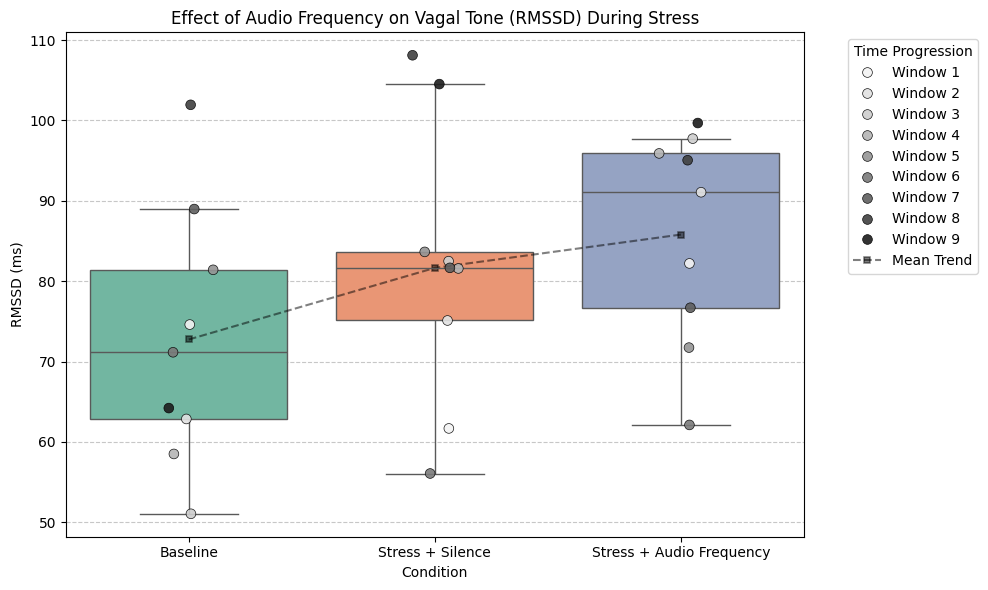

In [31]:
plt.figure(figsize=(10, 6))

# boxplot
sns.boxplot(x='Condition', y='HRV_RMSSD', data=stats_df, palette='Set2', showfliers=False, whis = (0, 90))

# stripplot with colored dot
#sns.stripplot(x='Condition', y='HRV_RMSSD', hue='Window_Label', data=stats_df, 
              #palette='Grays', size=7, alpha=0.9, dodge=False)
# The perfect stripplot code for Image 3
sns.stripplot(x='Condition', y='HRV_RMSSD', hue='Window_Label', data=stats_df,
              palette='Greys', size=7, alpha=0.9, dodge=False,
              linewidth=0.5, edgecolor='black') # Adds the border!



#trend line
sns.pointplot(x='Condition', y='HRV_RMSSD', data=stats_df, 
              color='black',     
              alpha=0.5,            
              linewidth=1.5,       
              markers='s',         
              linestyles='--',      
              errorbar=None,
              label='Mean Trend')

plt.title('Effect of Audio Frequency on Vagal Tone (RMSSD) During Stress')
plt.ylabel('RMSSD (ms)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Time Progression', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 

In [ ]:
#normality for HR
normality_hr = pg.normality(data=stats_df, dv='MeanHR', group='Condition')
normality_hr

In [ ]:
normality_hr.to_csv("normality_hr.csv")

In [ ]:
#variance for HR
homogeneity_hr = pg.homoscedasticity(data=stats_df, dv='MeanHR', group='Condition')
homogeneity_hr

In [ ]:
homogeneity_hr.to_csv("homogeneity_hr.csv")

In [ ]:
# ANOVA for HR
anova_hr = pg.anova(data=stats_df, dv='MeanHR', between='Condition')
anova_hr

In [ ]:
anova_hr.to_csv("anova_hr.csv")

In [ ]:
kruskal_results_hr = pg.kruskal(data=stats_df, dv='MeanHR', between='Condition')
kruskal_results_hr

In [ ]:
# effect size
H = kruskal_results_hr['H'][0]
k = 3  # number of group
n = len(stats_df)  

# calculate Eta-squared for Kruskal-Wallis
eta_sq_hr = (H - k + 1) / (n - k)

print(f"Effect Size: {eta_sq_hr:.3f}")

In [ ]:
# post-hoc tests (non-parametric)
posthoc_hr = pg.pairwise_tests(data=stats_df, 
                                  dv='MeanHR', 
                                  between='Condition', 
                                  parametric=False,  # non-parametric
                                  padjust='holm')    # Adjusts p-values for multiple comparisons

posthoc_hr

In [ ]:
posthoc_hr.to_csv("posthoc_hr.csv")

/var/folders/fv/xb9075755rb6ysj4m_w8p0x40000gn/T/ipykernel_91743/1699691005.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Condition', y='MeanHR', data=stats_df, palette='Set2', showfliers=False, whis= (0,90))


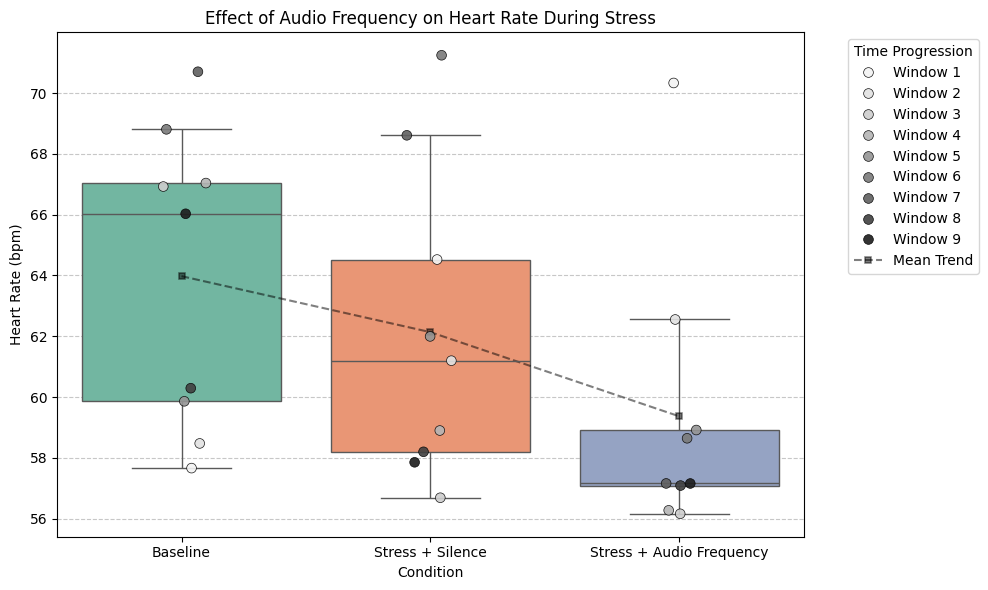

In [34]:
plt.figure(figsize=(10, 6))

# boxplot
sns.boxplot(x='Condition', y='MeanHR', data=stats_df, palette='Set2', showfliers=False, whis= (0,90))

# stripplot with colored dot
#sns.stripplot(x='Condition', y='MeanHR', hue='Window_Label', data=stats_df, 
              #palette='tab10', size=7, alpha=0.9, dodge=False)
# The perfect stripplot code for Image 3
sns.stripplot(x='Condition', y='MeanHR', hue='Window_Label', data=stats_df,
              palette='Greys', size=7, alpha=0.9, dodge=False,
              linewidth=0.5, edgecolor='black') # Adds the border!
#trend line
sns.pointplot(x='Condition', y='MeanHR', data=stats_df, 
              color='black',     
              alpha=0.5,            
              linewidth=1.5,       
              markers='s',         
              linestyles='--',      
              errorbar=None,
              label='Mean Trend')

plt.title('Effect of Audio Frequency on Heart Rate During Stress')
plt.ylabel('Heart Rate (bpm)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Time Progression', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 

In [ ]:
plt.figure(figsize=(10, 6))

# boxplot
sns.boxplot(x='Condition', y='HRV_SDNN', data=stats_df, palette='Set2', showfliers=False, whis = (0,75))

# stripplot with colored dot
#sns.stripplot(x='Condition', y='MeanHR', hue='Window_Label', data=stats_df, 
              #palette='tab10', size=7, alpha=0.9, dodge=False)
# The perfect stripplot code for Image 3
sns.stripplot(x='Condition', y='HRV_SDNN', hue='Window_Label', data=stats_df,
              palette='Greys', size=7, alpha=0.9, dodge=False,
              linewidth=0.5, edgecolor='black') # Adds the border!
#trend line
sns.pointplot(x='Condition', y='HRV_SDNN', data=stats_df, 
              color='black',     
              alpha=0.5,            
              linewidth=1.5,       
              markers='s',         
              linestyles='--',      
              errorbar=None,
              label='Mean Trend')

plt.title('Effect of Audio Frequency on SDNN During Stress')
plt.ylabel('SDNN (ms)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Time Progression', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() 

In [ ]:
#combine results into a dictionary
combined_results = {
    'Metric': ['HRV_RMSSD', 'Mean_HR'],
    'H_Statistic': [kruskal_results_rmssd['H'][0], kruskal_results_hr['H'][0]],
    'p_value': [kruskal_results_rmssd['p_unc'][0], kruskal_results_hr['p_unc'][0]],
    'Eta_Squared': [eta_sq_rmssd, eta_sq_hr]
}

#dataFrame
kruskal_summary_table = pd.DataFrame(combined_results)

# round 3 decimal places
kruskal_summary_table['H_Statistic'] = kruskal_summary_table['H_Statistic'].round(3)
kruskal_summary_table['p_value'] = kruskal_summary_table['p_value'].round(3)
kruskal_summary_table['Eta_Squared'] = kruskal_summary_table['Eta_Squared'].round(3)



kruskal_summary_table

In [ ]:
kruskal_summary_table.to_csv("kruskal_summary_table.csv")